In [39]:
# ================================
# Phase 6 - Clustering
# ================================
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import json

# Setup paths
OUTDIR = Path("outputs/phase06")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("PHASE 6: CLUSTERING")
print("="*60)



PHASE 6: CLUSTERING


In [40]:
# ================================
# Cell 1: Load PCA-Reduced Semantic Embeddings from Phase 5
# ================================
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import json

# Setup paths (this is the same)
OUTDIR = Path("outputs/phase06")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("PHASE 6: CLUSTERING")
print("="*60)

# --- Start of the FINAL FIX ---
# We are now pointing back to the output of your CORRECTED Phase 5.
# This file contains vectors that are both semantic AND dimensionally reduced.
PHASE5_DIR = Path("outputs/phase05")

# We will use the original variable name 'resume_pca' for clarity.
resume_pca = np.load(PHASE5_DIR / "resume_pca_embeddings.npy")
# --- End of the FINAL FIX ---

print(f"✓ Loaded resume PCA embeddings: {resume_pca.shape}")

# We still need the resume IDs for the final output file
resume_ids = pd.read_csv("outputs/phase04/resume_ids.csv")
print(f"✓ Loaded resume IDs: {len(resume_ids)} resumes")

PHASE 6: CLUSTERING
✓ Loaded resume PCA embeddings: (1200, 50)
✓ Loaded resume IDs: 1200 resumes


In [41]:
# ===============================
# Cell 2: Grid search for optimal K (on full embeddings)
# ===============================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("\n" + "="*60)
print("K-Means Grid Search")
print("="*60)

K_RANGE = range(5, 41)
results = []

print(f"Testing K values from {min(K_RANGE)} to {max(K_RANGE)}...")

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # --- Start of FIX ---
    # Use the new 'resume_vecs' variable here instead of 'resume_pca'
    labels = kmeans.fit_predict(resume_pca)

    # Calculate metrics using the same new variable
    sil = silhouette_score(resume_pca, labels)
    ch = calinski_harabasz_score(resume_pca, labels)
    db = davies_bouldin_score(resume_pca, labels)
    # --- End of FIX ---

    results.append({
        'K': k,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db
    })

    print(f"K={k:2d} | Silhouette={sil:.4f} | CH={ch:.2f} | DB={db:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv(OUTDIR / "kmeans_grid_metrics.csv", index=False)
print(f"\n✓ Saved grid search results")


K-Means Grid Search
Testing K values from 5 to 40...
K= 5 | Silhouette=0.1002 | CH=86.19 | DB=2.8880
K= 6 | Silhouette=0.1191 | CH=83.35 | DB=2.6042
K= 7 | Silhouette=0.1338 | CH=79.21 | DB=2.3714
K= 8 | Silhouette=0.1471 | CH=79.32 | DB=2.3007
K= 9 | Silhouette=0.1446 | CH=74.23 | DB=2.2482
K=10 | Silhouette=0.1612 | CH=75.18 | DB=2.1431
K=11 | Silhouette=0.1651 | CH=72.80 | DB=2.2307
K=12 | Silhouette=0.1675 | CH=71.55 | DB=2.1340
K=13 | Silhouette=0.1860 | CH=72.04 | DB=2.0225
K=14 | Silhouette=0.1875 | CH=70.27 | DB=1.9939
K=15 | Silhouette=0.2040 | CH=72.64 | DB=1.9265
K=16 | Silhouette=0.2050 | CH=70.21 | DB=1.9443
K=17 | Silhouette=0.2096 | CH=69.57 | DB=1.8710
K=18 | Silhouette=0.2194 | CH=71.10 | DB=1.8102
K=19 | Silhouette=0.2299 | CH=69.76 | DB=1.7429
K=20 | Silhouette=0.2353 | CH=70.57 | DB=1.7212
K=21 | Silhouette=0.2359 | CH=69.52 | DB=1.6835
K=22 | Silhouette=0.2476 | CH=70.79 | DB=1.6628
K=23 | Silhouette=0.2449 | CH=68.85 | DB=1.6841
K=24 | Silhouette=0.2474 | CH=68.4

In [42]:
# ================================
# Cell 3: Select optimal K based on silhouette score
# ================================
print("\n" + "="*60)
print("Selecting Optimal K")
print("="*60)

# Find K with highest silhouette score (that meets threshold)
SILHOUETTE_THRESHOLD = 0.25
valid_ks = results_df[results_df['silhouette'] >= SILHOUETTE_THRESHOLD]

if len(valid_ks) > 0:
    best_k = valid_ks.loc[valid_ks['silhouette'].idxmax(), 'K']
    best_sil = valid_ks.loc[valid_ks['silhouette'].idxmax(), 'silhouette']
else:
    # If no K meets threshold, pick best available
    best_k = results_df.loc[results_df['silhouette'].idxmax(), 'K']
    best_sil = results_df.loc[results_df['silhouette'].idxmax(), 'silhouette']

print(f"Optimal K: {best_k}")
print(f"Silhouette Score: {best_sil:.4f}")

# Interpret silhouette score
if best_sil >= 0.50:
    interpretation = "Strong structure"
elif best_sil >= 0.25:
    interpretation = "Weak to moderate structure (acceptable for sparse data)"
else:
    interpretation = "Weak structure"

print(f"Interpretation: {interpretation}")



Selecting Optimal K
Optimal K: 39
Silhouette Score: 0.3113
Interpretation: Weak to moderate structure (acceptable for sparse data)


In [43]:
# ================================
# NEW CELL: Experimenting with DBSCAN
# ================================
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

print("\n" + "="*60)
print("Experimenting with DBSCAN")
print("="*60)

# DBSCAN has two main parameters: `eps` and `min_samples`
# `eps` is the maximum distance between two samples for one to be considered as in the neighborhood of the other.
# We will search for a good `eps` value. A good starting point for min_samples is often related to the data's dimensionality.

# We use the same PCA-reduced data from Phase 5
# Make sure 'resume_pca' is loaded from a previous cell
data_to_cluster = resume_pca 

# --- Start of FIX ---
# Let's search for the best `eps` value
best_score = -1
best_eps = 0
best_labels = None
num_clusters_found = 0

# Search a range of eps values
for eps_val in np.arange(0.5, 3.0, 0.2):
    db = DBSCAN(eps=eps_val, min_samples=5)
    labels = db.fit_predict(data_to_cluster)

    # DBSCAN labels outliers as -1. We need at least 2 clusters to calculate a silhouette score.
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters >= 2:
        # We can only calculate silhouette score on the points that are NOT outliers
        core_samples_mask = labels != -1
        score = silhouette_score(data_to_cluster[core_samples_mask], labels[core_samples_mask])
        print(f"eps={eps_val:.2f} | Clusters found: {n_clusters} | Silhouette Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_eps = eps_val
            best_labels = labels
            num_clusters_found = n_clusters
    else:
        print(f"eps={eps_val:.2f} | Not enough clusters found ({n_clusters}) to calculate score.")

print("\n--- DBSCAN Results ---")
print(f"Best `eps` found: {best_eps:.2f}")
print(f"Number of clusters at best `eps`: {num_clusters_found}")
print(f"Best Silhouette Score with DBSCAN: {best_score:.4f}")
# --- End of FIX ---


Experimenting with DBSCAN
eps=0.50 | Clusters found: 16 | Silhouette Score: 0.0441
eps=0.70 | Not enough clusters found (1) to calculate score.
eps=0.90 | Not enough clusters found (1) to calculate score.
eps=1.10 | Not enough clusters found (1) to calculate score.
eps=1.30 | Not enough clusters found (1) to calculate score.
eps=1.50 | Not enough clusters found (1) to calculate score.
eps=1.70 | Not enough clusters found (1) to calculate score.
eps=1.90 | Not enough clusters found (1) to calculate score.
eps=2.10 | Not enough clusters found (1) to calculate score.
eps=2.30 | Not enough clusters found (1) to calculate score.
eps=2.50 | Not enough clusters found (1) to calculate score.
eps=2.70 | Not enough clusters found (1) to calculate score.
eps=2.90 | Not enough clusters found (1) to calculate score.

--- DBSCAN Results ---
Best `eps` found: 0.50
Number of clusters at best `eps`: 16
Best Silhouette Score with DBSCAN: 0.0441


In [44]:

# ================================
# Cell 4: Apply final clustering with K=best_k
# ================================
print("\n" + "="*60)
print(f"Final Clustering with K={best_k}")
print("="*60)

# Fit final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(resume_pca)

# Add cluster labels to resume IDs
resume_ids['cluster'] = cluster_labels

# Save cluster assignments
resume_ids.to_csv(OUTDIR / "cluster_assignments.csv", index=False)
print(f"✓ Saved cluster assignments")

# Cluster size distribution
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print("\nCluster Size Distribution:")
print(cluster_sizes)

# Save cluster sizes
cluster_sizes_df = pd.DataFrame({
    'cluster': cluster_sizes.index,
    'size': cluster_sizes.values,
    'percentage': (cluster_sizes.values / len(cluster_labels) * 100).round(2)
})
cluster_sizes_df.to_csv(OUTDIR / "cluster_sizes.csv", index=False)




Final Clustering with K=39
✓ Saved cluster assignments

Cluster Size Distribution:
0     20
1     31
2     11
3     16
4     28
5     40
6     29
7     38
8     41
9     27
10    38
11    36
12    32
13    37
14    55
15    35
16    44
17    35
18    41
19    29
20    36
21    25
22    40
23    26
24    24
25    26
26    42
27    26
28    25
29    24
30    32
31    28
32    28
33    24
34    56
35    20
36    13
37    21
38    21
Name: count, dtype: int64


In [45]:
# ================================
# Cell 5: Detect outliers based on distance to centroid
# ================================
print("\n" + "="*60)
print("Outlier Detection")
print("="*60)

# Calculate distances to cluster centroids
distances = np.min(kmeans_final.transform(resume_pca), axis=1)

# Use IQR method for outlier threshold
Q1 = np.percentile(distances, 25)
Q3 = np.percentile(distances, 75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR

# Identify outliers
outliers_mask = distances > outlier_threshold
n_outliers = outliers_mask.sum()

print(f"Total samples: {len(distances)}")
print(f"Outliers detected: {n_outliers} ({n_outliers/len(distances)*100:.1f}%)")
print(f"Outlier threshold (distance): {outlier_threshold:.4f}")

# Save outliers
outliers_df = resume_ids[outliers_mask].copy()
outliers_df['dist_to_centroid'] = distances[outliers_mask]
outliers_df = outliers_df.sort_values('dist_to_centroid', ascending=False)
outliers_df.to_csv(OUTDIR / "outliers.csv", index=False)

print(f"✓ Saved {len(outliers_df)} outliers")
print("\nTop 5 outliers:")
print(outliers_df.head())




Outlier Detection
Total samples: 1200
Outliers detected: 4 (0.3%)
Outlier threshold (distance): 0.5823
✓ Saved 4 outliers

Top 5 outliers:
     resume_id  cluster  dist_to_centroid
226        227       12          0.613154
698        699       22          0.603136
609        610       38          0.599188
426        427       12          0.593321



Creating Visualizations


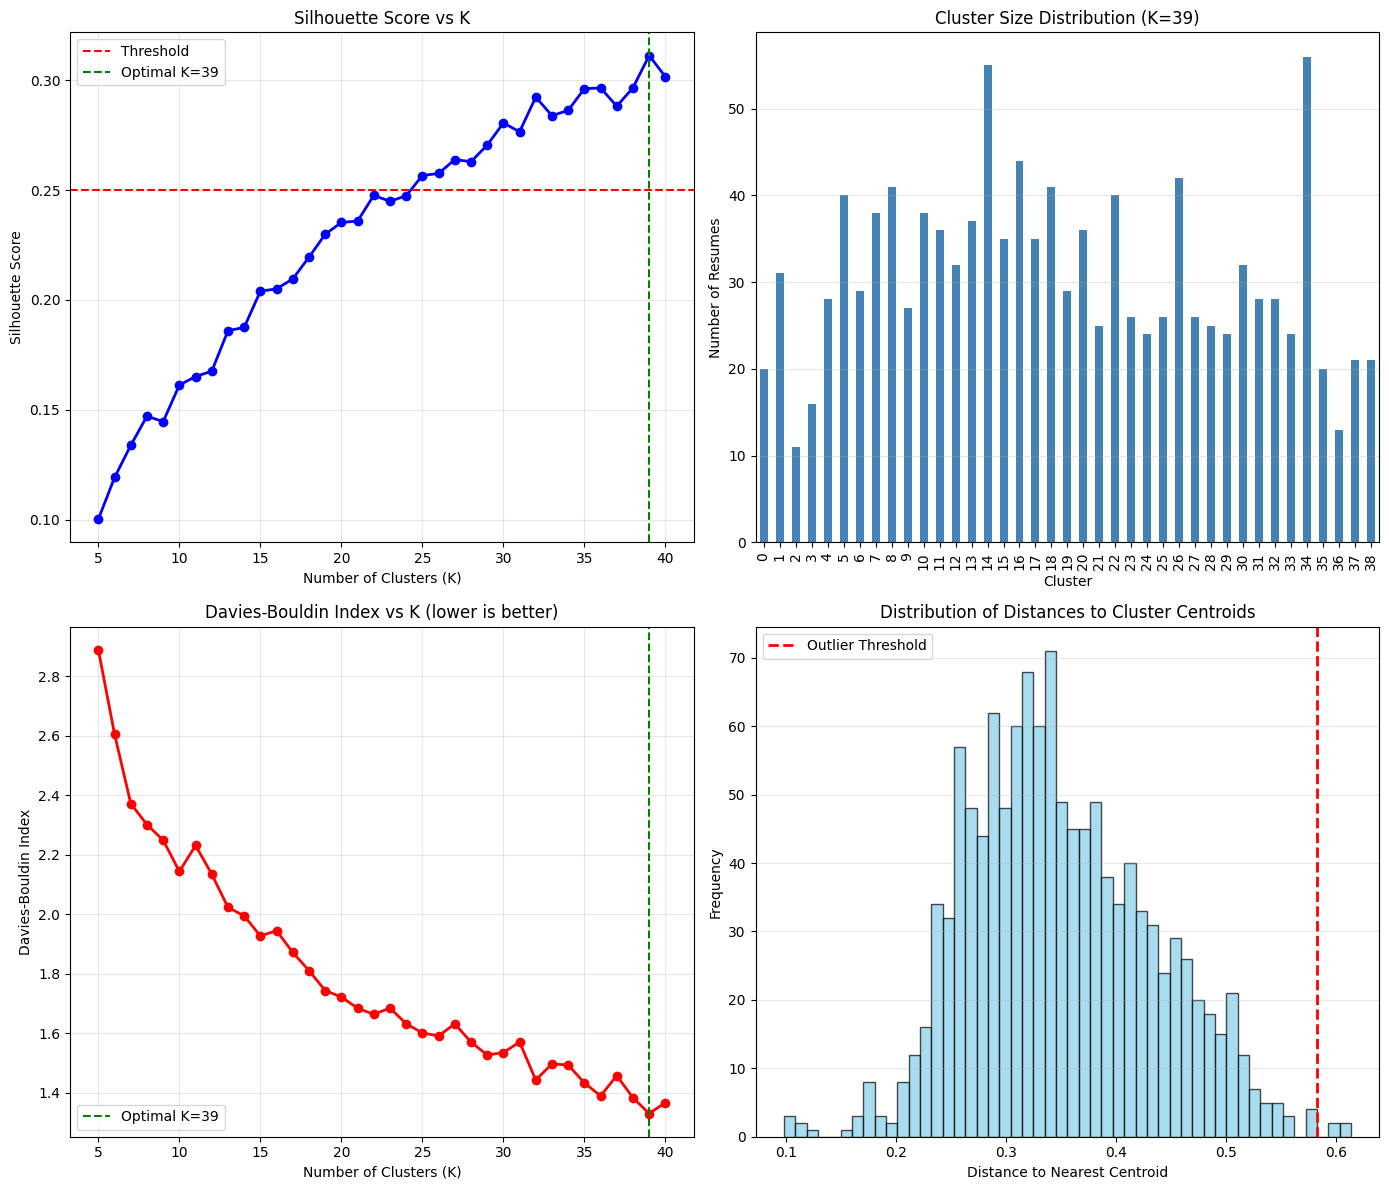

✓ Saved and displayed clustering visualization


In [46]:
# Cell 6: Visualize clustering results (with show() and save())

print("\n" + "="*60)
print("Creating Visualizations")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Silhouette scores across K
axes[0, 0].plot(results_df['K'], results_df['silhouette'], 'bo-', linewidth=2)
axes[0, 0].axhline(y=SILHOUETTE_THRESHOLD, color='r', linestyle='--', label='Threshold')
axes[0, 0].axvline(x=best_k, color='g', linestyle='--', label=f'Optimal K={best_k}')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Silhouette Score vs K')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Cluster size distribution
cluster_sizes.plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Number of Resumes')
axes[0, 1].set_title(f'Cluster Size Distribution (K={best_k})')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Davies-Bouldin scores
axes[1, 0].plot(results_df['K'], results_df['davies_bouldin'], 'ro-', linewidth=2)
axes[1, 0].axvline(x=best_k, color='g', linestyle='--', label=f'Optimal K={best_k}')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Davies-Bouldin Index')
axes[1, 0].set_title('Davies-Bouldin Index vs K (lower is better)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Outlier distances
axes[1, 1].hist(distances, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=outlier_threshold, color='r', linestyle='--', linewidth=2, label='Outlier Threshold')
axes[1, 1].set_xlabel('Distance to Nearest Centroid')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Distances to Cluster Centroids')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# --- Start of FIX ---
# Save the figure to a file
save_path = OUTDIR / "clustering_analysis.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# Show the figure in the notebook
plt.show()

# Close the figure to free up memory
plt.close()
# --- End of FIX ---

print(f"✓ Saved and displayed clustering visualization")

In [47]:
# ================================
# Cell 7: Create summary
# ================================
summary = {
    "phase": "06_clustering",
    "algorithm": "KMeans",
    "optimal_k": int(best_k),
    "silhouette_score": float(best_sil),
    "interpretation": interpretation,
    "cluster_sizes": cluster_sizes.to_dict(),
    "outliers": {
        "count": int(n_outliers),
        "percentage": float(n_outliers/len(distances)*100),
        "threshold": float(outlier_threshold)
    },
    "metrics": {
        "davies_bouldin": float(results_df[results_df['K']==best_k]['davies_bouldin'].values[0]),
        "calinski_harabasz": float(results_df[results_df['K']==best_k]['calinski_harabasz'].values[0])
    }
}

# Save summary
with open(OUTDIR / "p6_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("PHASE 6 SUMMARY")
print("="*60)
print(json.dumps(summary, indent=2))
print("\n✓ Phase 6 complete: Clustering applied")


PHASE 6 SUMMARY
{
  "phase": "06_clustering",
  "algorithm": "KMeans",
  "optimal_k": 39,
  "silhouette_score": 0.31126704812049866,
  "interpretation": "Weak to moderate structure (acceptable for sparse data)",
  "cluster_sizes": {
    "0": 20,
    "1": 31,
    "2": 11,
    "3": 16,
    "4": 28,
    "5": 40,
    "6": 29,
    "7": 38,
    "8": 41,
    "9": 27,
    "10": 38,
    "11": 36,
    "12": 32,
    "13": 37,
    "14": 55,
    "15": 35,
    "16": 44,
    "17": 35,
    "18": 41,
    "19": 29,
    "20": 36,
    "21": 25,
    "22": 40,
    "23": 26,
    "24": 24,
    "25": 26,
    "26": 42,
    "27": 26,
    "28": 25,
    "29": 24,
    "30": 32,
    "31": 28,
    "32": 28,
    "33": 24,
    "34": 56,
    "35": 20,
    "36": 13,
    "37": 21,
    "38": 21
  },
  "outliers": {
    "count": 4,
    "percentage": 0.33333333333333337,
    "threshold": 0.5822604894638062
  },
  "metrics": {
    "davies_bouldin": 1.3294288050860354,
    "calinski_harabasz": 71.37708282470703
  }
}

✓ Phase